# 样章 · 独立迁移实验

## 学习目标与先修知识

完成后，你能构造分段恒定输入（piecewise constant input），在时间网格（time grid）中保留输入变化点，并用独立解析解（analytical solution）核验数值结果。

**先修知识**：[从变化率进入微分方程](04-rates-ode.ipynb)中的解析解和 [检查数值模拟](05-numerical-checks.ipynb)中的误差与步长检查。


## 具体问题

相同的总流入，是否会给出相同的最终存量（stock）？比较 0—20 T 全程 u = 1 U/T，
与 0—10 T 输入 2 U/T、10—20 T 停止输入。其他条件相同，A₀ = 0 U、k = 0.5 /T。

## 初步实验

先核对两种方案都输入 20 U，再记录你的终点预测。较早进入的物质有更长时间被清除，
所以“总输入”可能还不足以确定“最后剩多少”。

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
from systems_science.theme import DATA_COLORS, SERIES_COLORS

plot_style()

In [2]:
boundaries = [0.0, 10.0, 20.0]
constant_rates = [1.0, 1.0]
front_loaded_rates = [2.0, 0.0]
total_constant = np.dot(np.diff(boundaries), constant_rates)
total_front = np.dot(np.diff(boundaries), front_loaded_rates)
assert total_constant == total_front == 20
print(f"两种方案的总输入都是 {total_constant:g} U")

两种方案的总输入都是 20 U


## 模型假设

把研究对象看成一个**充分混合的单室模型（one-compartment model）**：用一个数描述室内示踪物质（tracer）总量。
示踪物质只是便于思考的标记物。本单元使用人工单位 U 与 T，参数（parameter）是教学选择，
不对应具体药物、患者或真实生理测量。边界外的输入被视为已知；不讨论组织容积、
浓度（concentration）、多室交换或观测噪声。A 是物质量，不是浓度。

| 量 | 含义 | 单位与条件 |
|---|---|---|
| $t$ | 从实验起点经过的时间 | T，$t\geq0$ |
| $A$、$A_0$ | 当前与初始物质量 | U，连续模型非负 |
| $u$ | 流入速率 | U/T，非负 |
| $k$ | 比例清除系数（elimination rate constant） | 1/T，非负 |
| $h$ | 计算时间步长（time step） | T，正数 |

假设清除速率为 $kA$，单位是 U/T。这个比例关系是一项建模假设，
不代表所有物质在任意条件下都按同一机制清除。

## 数学解释与推导

分段恒定输入允许 u 在指定时刻改变。
第 j 段从 $b_j$ 到 $b_{j+1}$，流率为 $u_j$。段内仍满足 $A'=u_j-kA$；
把该段起点存量记为 $a_j$，经过 $\tau=t-b_j$ 后，k > 0 时：

$$A(t)=a_je^{-k\tau}+\frac{u_j}{k}(1-e^{-k\tau}).$$

本段终点就是下一段初值（initial condition）。输入改变时，存量连续，变化率可以跳变；本单元没有瞬间注入的脉冲量。
总输入为 $\sum_j u_j(b_{j+1}-b_j)$。每段的数值步长必须在输入改变时截断，
不能让一个跨越变化点的步长仍使用旧流率。

这里解析参考的每段起点必须来自**上一段的解析终点**，不能偷用 欧拉法（forward Euler method） 终点，
否则参考值也混入了待检验方法的误差。

## 核心实现

保留解析函数，再按输入段显式构造更新。即使 h 不能整除某段长度，
最后一小步也会落在该段终点。返回的 `used_rates` 对应每一个时间区间。

In [3]:
def exact_amount(t, u=1.0, k=0.5, A0=0.0):
    """恒定输入解析解，显式处理零清除与很小的 k。"""
    t = np.asarray(t, dtype=float)
    if not np.all(np.isfinite(t)) or np.any(t < 0):
        raise ValueError("时间必须有限且非负")
    if not all(np.isfinite(v) and v >= 0 for v in (u, k, A0)):
        raise ValueError("模型参数必须有限且非负")
    if k == 0:
        return A0 + u * t
    # expm1(x) 计算 exp(x)-1，避免小 x 时两个接近的数相减。
    return A0 * np.exp(-k * t) + u * (-np.expm1(-k * t) / k)

In [4]:
def piecewise_experiment(boundaries, rates, k=0.5, A0=0.0, h=0.1):
    """每段单独划分网格，显式落在所有输入变化时刻。"""
    boundaries = np.asarray(boundaries, dtype=float)
    rates = np.asarray(rates, dtype=float)
    if boundaries.ndim != 1 or rates.ndim != 1 or len(boundaries) != len(rates) + 1:
        raise ValueError("m 个输入段需要 m+1 个边界")
    if len(rates) == 0 or boundaries[0] != 0 or not np.all(np.diff(boundaries) > 0):
        raise ValueError("边界从 0 开始且严格递增")
    if not np.all(np.isfinite(boundaries)) or not np.all(np.isfinite(rates)) or np.any(rates < 0):
        raise ValueError("边界有限，输入有限且非负")
    if not all(np.isfinite(v) for v in (k, A0, h)) or min(k, A0) < 0 or h <= 0:
        raise ValueError("k、A0 非负，h 为正")
    times, amounts, reference = [0.0], [float(A0)], [float(A0)]
    used_rates = []
    for start, stop, input_rate in zip(boundaries[:-1], boundaries[1:], rates):
        reference_start = reference[-1]
        duration = stop - start
        n_steps = max(1, int(np.ceil(duration / h)))
        # 最后一小步可以短于 h；不让一个步长跨过输入改变的时刻。
        grid = np.minimum(start + np.arange(1, n_steps + 1) * h, stop)
        grid[-1] = stop
        grid = np.unique(grid)
        for end in grid:
            dt = end - times[-1]
            amounts.append(amounts[-1] + dt * (input_rate - k * amounts[-1]))
            times.append(float(end))
            used_rates.append(float(input_rate))
            reference.append(float(exact_amount(end-start, input_rate, k, reference_start)))
    return tuple(np.asarray(values) for values in (times, amounts, reference, used_rates))

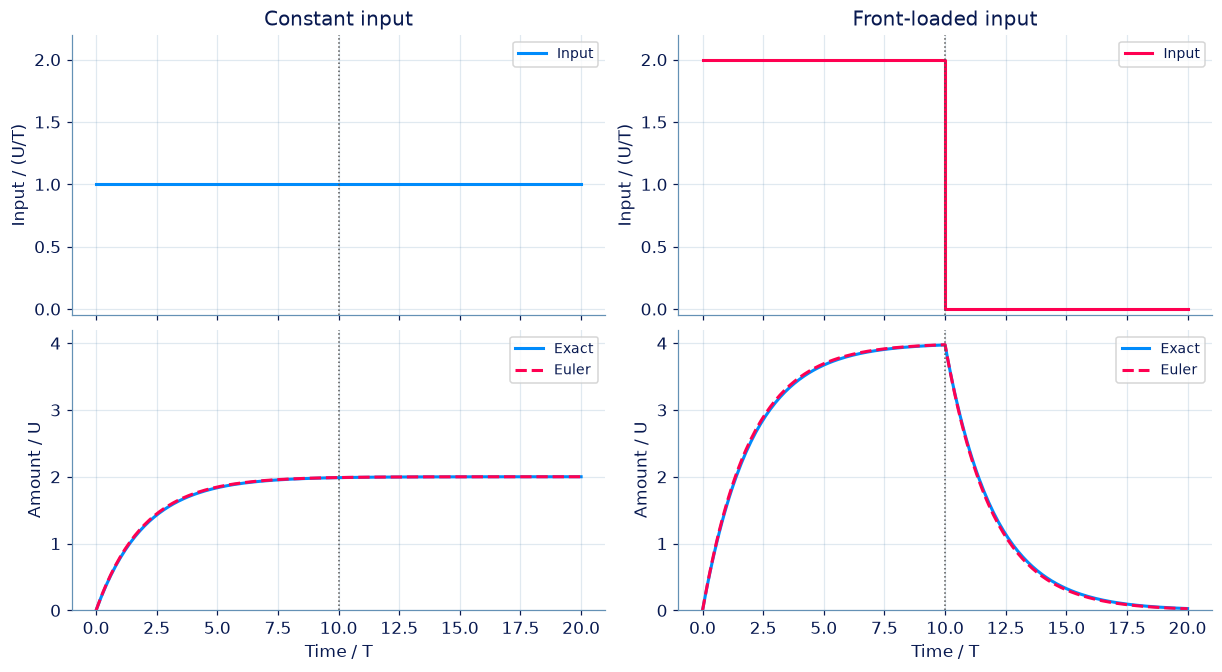

| 输入方案 | 解析终点 / U | Euler 终点 / U | 最大误差 / U |
| --- | --- | --- | --- |
| 恒定 | 1.99991 | 1.99993 | 0.018787 |
| 前置 | 0.0267702 | 0.0235419 | 0.0375741 |

In [5]:
constant = piecewise_experiment(boundaries, constant_rates)
front = piecewise_experiment(boundaries, front_loaded_rates)
fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True)
for column, (result, rates, label) in enumerate([(constant, constant_rates, "Constant input"),
                                               (front, front_loaded_rates, "Front-loaded input")]):
    t, a, reference, used_rates = result
    axes[0, column].step(boundaries, list(rates)+[rates[-1]], where="post", label="Input", color=DATA_COLORS[column])
    axes[1, column].plot(t, reference, color=SERIES_COLORS["exact"], label="Exact")
    axes[1, column].plot(t, a, "--", color=SERIES_COLORS["euler"], label="Euler")
    assert 10 in t and t[-1] == 20
    residual = np.diff(a) - np.diff(t)*(used_rates - 0.5*a[:-1])
    assert np.max(np.abs(residual)) < 1e-10
    axes[0, column].set(ylabel="Input / (U/T)", title=label, ylim=(-0.05, 2.2))
    axes[1, column].set(xlabel="Time / T", ylabel="Amount / U", ylim=(0, 4.2))
for ax in axes.flat:
    ax.axvline(10, color=SERIES_COLORS["reference"], linestyle=":", linewidth=1)
    ax.legend(fontsize=9)
plt.show()
display(Markdown(show_table(["输入方案", "解析终点 / U", "Euler 终点 / U", "最大误差 / U"],
    [[name, result[2][-1], result[1][-1], np.max(np.abs(result[1]-result[2]))]
     for name, result in [("恒定", constant), ("前置", front)]])))

## 对照实验

先减半步长检查结论是否被数值误差（numerical error）左右，再关闭清除 k = 0：此时同样的总输入应该留下同样多的物质。
最后把变化时刻改为 7.3 T，使用 h = 0.4 T，确认不对齐的变化点仍被正确处理。

In [6]:
front_errors = []
for step in [0.2, 0.1, 0.05]:
    t, a, reference, _ = piecewise_experiment(boundaries, front_loaded_rates, h=step)
    front_errors.append(np.max(np.abs(a-reference)))
assert np.all(np.diff(front_errors) < 0)
for rates in [constant_rates, front_loaded_rates]:
    t, a, reference, _ = piecewise_experiment(boundaries, rates, k=0)
    assert np.allclose(a, reference)
    assert np.isclose(a[-1], 20)
odd_t, odd_a, odd_ref, odd_u = piecewise_experiment([0, 7.3, 20], [2, 0], h=0.4)
assert 7.3 in odd_t
assert np.all(np.diff(odd_t) > 0)
assert np.max(np.diff(odd_t)) <= 0.4 + 1e-10
print("前置输入的最大误差（h=0.2、0.1、0.05 T）：", np.round(front_errors, 6))
print("7.3 T 已成为网格点；零清除时两种方案都留下 20 U。")

前置输入的最大误差（h=0.2、0.1、0.05 T）： [0.076804 0.037574 0.018588]
7.3 T 已成为网格点；零清除时两种方案都留下 20 U。


## 结果解释

有清除时，恒定输入在 20 T 留下约 1.999909 U，前置输入只留下约 0.026770 U。
早期流入有更长时间被清除，所以相同总输入不保证相同终点。零清除时这个差异消失，
说明差异来自“输入时序与清除机制的相互作用”，而不是总量账目不一致。
这只支持当前线性、充分混合模型的结论；改变清除机制可能改变比较结果。

## 练习与参考资料

先独立作答，再提交核对。每道题的题面和输入输出示例如下。

### 第 1 题 · 单项选择题：输入突变和存量连续

分段恒定输入（piecewise constant input）在 10 T 改变流率，但没有瞬时注入的额外物质量。哪项正确？

- **A.** 存量（stock）保持连续，变化率可以跳变
- **B.** 流率翻倍时存量必须立即翻倍
- **C.** 任何输入变化都会让存量跳变
- **D.** 可直接把流率差当作存量差相加

[作答：输入突变和存量连续](http://127.0.0.1:8000/samples/accumulation-clearance/practice/?question=input-jump)

### 第 2 题 · Python 计算题：计算分段输入的解析终点

对分段恒定输入（piecewise constant input）逐段应用解析解（analytical solution），比较输入时序对终点存量（stock）的影响。

**函数与代码模板**

```python
def solve(
    bounds: list[float],
    rates: list[float],
    k: float,
    A0: float,
) -> tuple[float, float]:
    # 依次返回 total_input, final。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `bounds` | `list[float]` | 各段的起止时刻；第 i 段是 bounds[i] 到 bounds[i+1]。 | T |
| `rates` | `list[float]` | rates[i] 是第 i 段内保持不变的流入速率。 | U/T |
| `k` | `float` | 清除系数（elimination rate constant）；物质量为 A 时，清除流率为 k·A。 | 1/T |
| `A0` | `float` | 计算开始时的物质量。 | U |

**返回值**

按以下顺序返回元组：(total_input, final)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `total_input` | `float` | 各段流入速率×时长的总和，尚未扣除清除。 | U |
| `final` | `float` | 最后一个时刻 bounds[-1] 的解析物质量。 | U |

**计算规则**

从 A0 出发，逐段用该段流入速率及清除系数计算解析终点，并将它作为下一段的起点。累计各段输入量，依次返回 (total_input, final)。k=0 的一段只增加“流入速率×时长”。

**约束与边界**

- bounds 从 0 开始、严格递增，有 2 到 101 项，最后时刻不超过 100 T。
- len(rates)=len(bounds)−1；0 ≤ rates[i]、A0 ≤ 100，0 ≤ k ≤ 1。
- 每段都使用上一段的解析终点；不使用离散更新近似解析终点。

**输入样例**

以下是一组传给 solve 的参数；U、T 分别是物质量与时间单位。每个参数直接对应上方函数签名中的同名变量。

给定条件

| 量的含义 | 函数参数 | 给定值 | 单位 |
| --- | --- | --- | --- |
| 清除系数 | k | 0.5 | 1/T |
| 初始物质量 | A0 | 0 | U |

每段采用给定的恒定输入

| 时段 bounds / T | 流入速率 rates / (U/T) |
| --- | --- |
| 0 → 10 | 0 |
| 10 → 20 | 2 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
bounds = [0, 10, 20]
rates = [0, 2]
k = 0.5
A0 = 0

result = solve(bounds, rates, k, A0)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 量的含义 | 返回量 | 结果 | 单位 |
| --- | --- | --- | --- |
| 整个区间的总输入量 | total_input | 20 | U |
| 终点物质量 | final | ≈ 3.973048 | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (20.0, 3.973048212003658)
```

**样例解释**

前 10 T 没有流入，物质量保持为零；后 10 T 以 2 U/T 流入，总输入为 20 U。清除持续发生，所以终点为 4·(1−exp(−5))≈3.973048212 U。

数值核验允许绝对误差 1e-08 或相对误差 1e-07；允许使用 Python 标准库。

[作答：计算分段输入的解析终点](http://127.0.0.1:8000/samples/accumulation-clearance/practice/?question=piecewise-input)

### 第 3 题 · Python 计算题：在输入变化点截断步长

为分段恒定输入（piecewise constant input）构造时间网格（time grid），用显式欧拉法（forward Euler method）计算并以独立的分段解析解（analytical solution）核验。

**函数与代码模板**

```python
def solve(
    bounds: list[float],
    rates: list[float],
    k: float,
    A0: float,
    h: float,
) -> tuple[list[float], list[float], list[float], float]:
    # 依次返回 times, amounts, exact, max_error。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `bounds` | `list[float]` | 各段的起止时刻；第 i 段是 bounds[i] 到 bounds[i+1]。 | T |
| `rates` | `list[float]` | rates[i] 是第 i 段内保持不变的流入速率。 | U/T |
| `k` | `float` | 清除系数（elimination rate constant）；物质量为 A 时，清除流率为 k·A。 | 1/T |
| `A0` | `float` | 计算开始时的物质量。 | U |
| `h` | `float` | 每次更新跨过的时间间隔。 | T |

**返回值**

按以下顺序返回元组：(times, amounts, exact, max_error)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `times` | `list[float]` | 从 0 到终点的时间网格，包含所有变化点且无重复。 | T |
| `amounts` | `list[float]` | 与 times 对应的数值物质量，第一项为 A0。 | U |
| `exact` | `list[float]` | 与 times 对应的分段解析物质量，第一项为 A0。 | U |
| `max_error` | `float` | 同一时刻的数值结果与解析结果之间的最大绝对差。 | U |

**计算规则**

每段从左端重新以 h 前进；若下一步越过右端，就缩短该步，恰好落在右端。按实际步长更新 A_next=A+Δt·(u−k·A)，变化点只保留一次。解析轨迹独立逐段计算，依次返回 (times, amounts, exact, max_error)。

**约束与边界**

- bounds 从 0 开始、严格递增，有 2 到 101 项，最后时刻不超过 100 T；len(rates)=len(bounds)−1。
- 0 ≤ rates[i]、A0 ≤ 100，0 ≤ k ≤ 1，0 < h ≤ 5；给定条件保证总更新次数不超过 10000，所有计算结果有限。
- 三个列表等长，包含初值（initial condition）与最终时刻；变化点之后使用新一段的流入速率。
- 解析段的起点必须来自上一段解析终点；不使用 Euler 数值终点替代。

**输入样例**

以下是一组传给 solve 的参数；U、T 分别是物质量与时间单位。每个参数直接对应上方函数签名中的同名变量。

给定条件

| 量的含义 | 函数参数 | 给定值 | 单位 |
| --- | --- | --- | --- |
| 清除系数 | k | 0.5 | 1/T |
| 初始物质量 | A0 | 0 | U |
| 时间步长 | h | 1 | T |

每段采用给定的恒定输入

| 时段 bounds / T | 流入速率 rates / (U/T) |
| --- | --- |
| 0 → 1 | 1 |
| 1 → 2 | 0 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
bounds = [0, 1, 2]
rates = [1, 0]
k = 0.5
A0 = 0
h = 1

result = solve(bounds, rates, k, A0, h)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

对应时刻的两种计算结果

| 时刻 times / T | 数值物质量 amounts / U | 解析物质量 exact / U |
| --- | --- | --- |
| 0 | 0 | 0 |
| 1 | 1 | ≈ 0.7869387 |
| 2 | 0.5 | ≈ 0.4773024 |

计算结果

| 量的含义 | 返回量 | 结果 | 单位 |
| --- | --- | --- | --- |
| 网格上的最大误差 | max_error | ≈ 0.2130613 | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([0, 1, 2],
                   [0, 1.0, 0.5],
                   [0,
                    0.7869386805747333,
                    0.4773024370823823],
                   0.21306131942526674)
```

**样例解释**

在 [0,1] 内流入为 1，第一步得到 1 U；在 [1,2] 内流入变为 0，第二步得到 0.5 U。网格为 [0,1,2]，解析值约为 [0,0.7869387,0.4773024]，最大差出现在 t=1。

数值核验允许绝对误差 1e-08 或相对误差 1e-07；允许使用 Python 标准库。

[作答：在输入变化点截断步长](http://127.0.0.1:8000/samples/accumulation-clearance/practice/?question=align-change-points)

### 第 4 题 · 单项选择题：相同总输入是否意味着相同终点

对 dA/dt = u(t) − kA，取 k>0，初始物质量为零。两种方案在同一观察区间内输入相同总量：方案甲集中在早期，方案乙集中在晚期。哪一项解释合理？

- **A.** 终点一定相同，因为总输入相同
- **B.** 晚期输入经历清除的时间更短，终点可以更高
- **C.** 早期输入总会使终点更高
- **D.** 输入时间不属于模型的条件

[作答：相同总输入是否意味着相同终点](http://127.0.0.1:8000/samples/accumulation-clearance/practice/?question=input-timing)

**进一步阅读**：[MIT 一阶线性方程](https://ocw.mit.edu/courses/18-03sc-differential-equations-fall-2011/pages/unit-i-first-order-differential-equations/first-order-linear-odes/)：每段解析传播的基础。本节讲解、推导组织和代码为本项目编写。

[返回单元入口](README.md) · [单元目录](README.md)


[观察存量与流量](http://127.0.0.1:8000/samples/accumulation-clearance/explore/#stock-flow) · [比较步长与数值误差](http://127.0.0.1:8000/samples/accumulation-clearance/explore/#step-size) · [学习指南](../../../docs/学习指南.md)
